# Bibliotekos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats

from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Duomenys

In [2]:
data = pd.read_csv("../datasets_prep/dm_project_dataset.csv")
data['observationTime'] = pd.to_datetime(data['observationTime'])
data.columns

Index(['observationTime', 'absorbing_aerosol_index',
       'NO2_column_number_density', 'stratospheric_NO2_column_number_density',
       'NO2_slant_column_number_density', 'tropopause_pressure',
       'H2O_column_number_density', 'BrO', 'BrO_Error', 'NO2', 'NO2_Error',
       'O3', 'O3_Error', 'pm10', 'pm2p5', 'sia', 'nmvoc', 'dust', 'nh3',
       'pans', 'tp', 't2m', 'airTemperature', 'seaLevelPressure',
       'relativeHumidity', 'missforest_precipitation', 'xgb_cloudCover',
       'feelsLikeTemperature_fixed', 'windSpeed_fixed', 'windGust_fixed',
       'windDirection_fixed'],
      dtype='object')

In [3]:
data = data.drop(columns=['BrO_Error', 'NO2_Error', 'O3_Error'])
data['month'] = data['observationTime'].dt.month
data['day_of_year'] = data['observationTime'].dt.dayofyear
data['day_of_week'] = data['observationTime'].dt.dayofweek

In [4]:
data.columns

Index(['observationTime', 'absorbing_aerosol_index',
       'NO2_column_number_density', 'stratospheric_NO2_column_number_density',
       'NO2_slant_column_number_density', 'tropopause_pressure',
       'H2O_column_number_density', 'BrO', 'NO2', 'O3', 'pm10', 'pm2p5', 'sia',
       'nmvoc', 'dust', 'nh3', 'pans', 'tp', 't2m', 'airTemperature',
       'seaLevelPressure', 'relativeHumidity', 'missforest_precipitation',
       'xgb_cloudCover', 'feelsLikeTemperature_fixed', 'windSpeed_fixed',
       'windGust_fixed', 'windDirection_fixed', 'month', 'day_of_year',
       'day_of_week'],
      dtype='object')

# Random Forest realizacija

## Aibių sudarymas

In [5]:
data['target_precipitation'] = data['missforest_precipitation'].shift(-1)
data = data.dropna(subset=['target_precipitation'])

In [6]:
train_end = '2024-07-01'
val_end = '2025-02-01'

train = data[data['observationTime'] < train_end]
val = data[(data['observationTime'] >= train_end) & (data['observationTime'] <= val_end)]
test  = data[data['observationTime'] > val_end]

print(f"Train: {train.shape}, nuo {train['observationTime'].min()} iki {train['observationTime'].max()}")
print(f"Val: {val.shape}, nuo {val['observationTime'].min()} iki {val['observationTime'].max()}")
print(f"Test:  {test.shape},  nuo {test['observationTime'].min()} iki {test['observationTime'].max()}")

Train: (2192, 32), nuo 2018-07-01 00:00:00 iki 2024-06-30 00:00:00
Val: (216, 32), nuo 2024-07-01 00:00:00 iki 2025-02-01 00:00:00
Test:  (363, 32),  nuo 2025-02-02 00:00:00 iki 2026-01-30 00:00:00


In [7]:
target = 'target_precipitation'
drop_cols = ['observationTime', 't2m', target]

X_train = train.drop(columns=drop_cols)
y_train = train[target]

X_val = val.drop(columns=drop_cols)
y_val = val[target]

X_test = test.drop(columns=drop_cols)
y_test = test[target]

Min-max

In [8]:
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()

# X_train_norm = scaler.fit_transform(X_train)
# X_val_norm = scaler.transform(X_val)
# X_test_norm = scaler.transform(X_test)

## Standartiniai hiperparametrai

### Požymiai

Vėlavimai

In [9]:
# # column = ['tp', 'pm10', 'dust', 'H2O_column_number_density', 'absorbing_aerosol_index', 'airTemperature', 'O3', 'pans', 'NO2_slant_column_number_density', 'month', 'relativeHumidity', 'feelsLikeTemperature_fixed', 'sia', 'nh3']
# # column = ['tp', 'pm10', 'H2O_column_number_density', 'dust', 'nh3', 'absorbing_aerosol_index', 'O3', 'sia', 'feelsLikeTemperature_fixed', 'pans']
# column = ['tp', 'pm10', 'dust', 'nh3', 'seaLevelPressure', 'absorbing_aerosol_index', 'NO2_column_number_density', 'relativeHumidity',
#           'xgb_cloudCover', 'stratospheric_NO2_column_number_density', 'day_of_week', 'O3', 'pans', 'sia', 'NO2_slant_column_number_density',
#           'windGust_fixed', 'H2O_column_number_density', 'NO2', 'tropopause_pressure']
column = ['tp', 'pm10', 'H2O_column_number_density', 'dust', 'O3', 'absorbing_aerosol_index', 'sia', 'NO2_column_number_density',
           'pans', 'nh3', 'NO2_slant_column_number_density', 'seaLevelPressure', 'NO2']
X_train = X_train[column]
X_val = X_val[column]
X_test = X_test[column]

In [10]:
# X_train['NO2_column_number_density_lag-1'] = train['NO2_column_number_density'].shift(1)
# X_val['NO2_column_number_density_lag-1'] = val['NO2_column_number_density'].shift(1)
# X_test['NO2_column_number_density_lag-1'] = test['NO2_column_number_density'].shift(1)

# X_train['stratospheric_NO2_column_number_density_lag-1'] = train['stratospheric_NO2_column_number_density'].shift(1)
# X_val['stratospheric_NO2_column_number_density_lag-1'] = val['stratospheric_NO2_column_number_density'].shift(1)
# X_test['stratospheric_NO2_column_number_density_lag-1'] = test['stratospheric_NO2_column_number_density'].shift(1)

# X_train['tropopause_pressure_lag-1'] = train['tropopause_pressure'].shift(1)
# X_val['tropopause_pressure_lag-1'] = val['tropopause_pressure'].shift(1)
# X_test['tropopause_pressure_lag-1'] = test['tropopause_pressure'].shift(1)

X_train['H2O_column_number_density_lag-1'] = train['H2O_column_number_density'].shift(1)
X_val['H2O_column_number_density_lag-1'] = val['H2O_column_number_density'].shift(1)
X_test['H2O_column_number_density_lag-1'] = test['H2O_column_number_density'].shift(1)

# X_train['NO2_lag-1'] = train['NO2'].shift(1)
# X_val['NO2_lag-1'] = val['NO2'].shift(1)
# X_test['NO2_lag-1'] = test['NO2'].shift(1)


X_train['dust_lag-1'] = train['dust'].shift(1)
X_val['dust_lag-1'] = val['dust'].shift(1)
X_test['dust_lag-1'] = test['dust'].shift(1)

# X_train['dust_lag-5'] = train['dust'].shift(5)
# X_val['dust_lag-5'] = val['dust'].shift(5)
# X_test['dust_lag-5'] = test['dust'].shift(5)

X_train['pans_lag-10'] = train['pans'].shift(10)
X_val['pans_lag-10'] = val['pans'].shift(10)
X_test['pans_lag-10'] = test['pans'].shift(10)

# X_train['nmvoc_lag-2'] = train['nmvoc'].shift(2)
# X_val['nmvoc_lag-2'] = val['nmvoc'].shift(2)
# X_test['nmvoc_lag-2'] = test['nmvoc'].shift(2)

X_train['nh3_lag-1'] = train['nh3'].shift(1)
X_val['nh3_lag-1'] = val['nh3'].shift(1)
X_test['nh3_lag-1'] = test['nh3'].shift(1)

# X_train['nh3_lag-11'] = train['nh3'].shift(11)
# X_val['nh3_lag-11'] = val['nh3'].shift(11)
# X_test['nh3_lag-11'] = test['nh3'].shift(11)

# X_train['pm10_lag-1'] = train['pm10'].shift(1)
# X_val['pm10_lag-1'] = val['pm10'].shift(1)
# X_test['pm10_lag-1'] = test['pm10'].shift(1)

# X_train['pm2p5_lag-1'] = train['pm2p5'].shift(1)
# X_val['pm2p5_lag-1'] = val['pm2p5'].shift(1)
# X_test['pm2p5_lag-1'] = test['pm2p5'].shift(1)

# X_train['absorbing_aerosol_index_lag-8'] = train['absorbing_aerosol_index'].shift(8)
# X_val['absorbing_aerosol_index_lag-8'] = val['absorbing_aerosol_index'].shift(8)
# X_test['absorbing_aerosol_index_lag-8'] = test['absorbing_aerosol_index'].shift(8)

In [11]:
# data['precip_rolling_mean_3'] = data['missforest_precipitation'].rolling(window=3).mean()
# data['NO2_mean_7'] = data['NO2'].rolling(window=7).mean()

X_train['NO2_mean_7'] = train['NO2'].rolling(window=7).mean()
X_val['NO2_mean_7'] = val['NO2'].rolling(window=7).mean()
X_test['NO2_mean_7'] = test['NO2'].rolling(window=7).mean()

X_train['nmvoc_mean_5'] = train['nmvoc'].rolling(window=5).mean()
X_val['nmvoc_mean_5'] = val['nmvoc'].rolling(window=5).mean()
X_test['nmvoc_mean_5'] = test['nmvoc'].rolling(window=5).mean()

# X_train['dust_mean_7'] = train['dust'].rolling(window=7).mean()
# X_val['dust_mean_7'] = val['dust'].rolling(window=7).mean()
# X_test['dust_mean_7'] = test['dust'].rolling(window=7).mean()

# X_train['pm10_mean_5'] = train['pm10'].rolling(window=5).mean()
# X_val['pm10_mean_5'] = val['pm10'].rolling(window=5).mean()
# X_test['pm10_mean_5'] = test['pm10'].rolling(window=5).mean()

### Realizacija

In [12]:
rf_default = RandomForestRegressor(random_state=123)
rf_default.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [13]:
rf_default_pred_val = rf_default.predict(X_val)

### Metrikos

In [14]:
def metrics_fun(y_val, rf_pred_val):
    print(f'R^2:  {r2_score(y_val, rf_pred_val)}')
    print(f'MAE:  {mean_absolute_error(y_val, rf_pred_val)}')
    print(f'RMSE: {np.sqrt(mean_squared_error(y_val, rf_pred_val))}')

    corr, p_value = stats.spearmanr(y_val, rf_pred_val)
    print(f"r_s:  {corr:.3f}")

metrics_fun(y_val, rf_default_pred_val)

R^2:  0.46999335008777765
MAE:  1.5037453703703705
RMSE: 4.117100436229548
r_s:  0.692


### Vizualizacija

In [15]:
plot_df = val[['observationTime', 'target_precipitation']].copy()
plot_df['prediction'] = rf_default_pred_val
plot_df = plot_df.sort_values('observationTime')

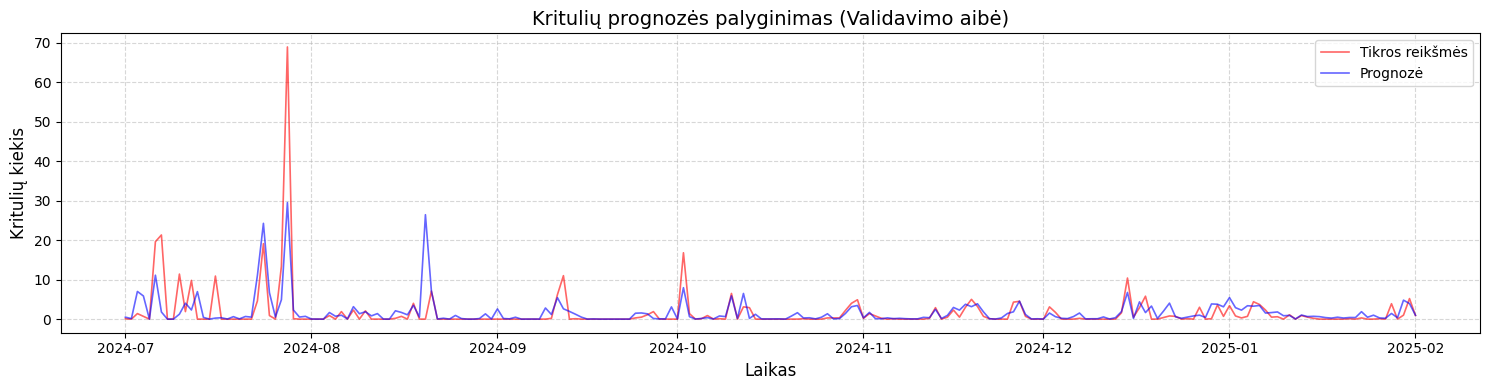

In [16]:
fig, ax1 = plt.subplots(figsize=(15, 4))
ax1.plot(plot_df['observationTime'], plot_df['target_precipitation'], label='Tikros reikšmės', color='red', linewidth=1.2, alpha=0.6)
ax1.plot(plot_df['observationTime'], plot_df['prediction'], label='Prognozė', color='blue', linewidth=1.2, alpha=0.6)
ax1.legend(loc='upper right', fontsize=10, frameon=True)
ax1.set_title("Kritulių prognozės palyginimas (Validavimo aibė)", fontsize=14)
ax1.set_xlabel("Laikas", fontsize=12)
ax1.set_ylabel("Kritulių kiekis", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()

### Požymių reikšmingumas

In [17]:
rf_default_importances = rf_default.feature_importances_
rf_default_importances

array([0.51593566, 0.04586896, 0.04602092, 0.0289985 , 0.02430223,
       0.02283585, 0.01218378, 0.01906812, 0.01650888, 0.02024567,
       0.01780548, 0.01980519, 0.01103474, 0.06654372, 0.04645155,
       0.02106276, 0.02302584, 0.02607526, 0.01622691])

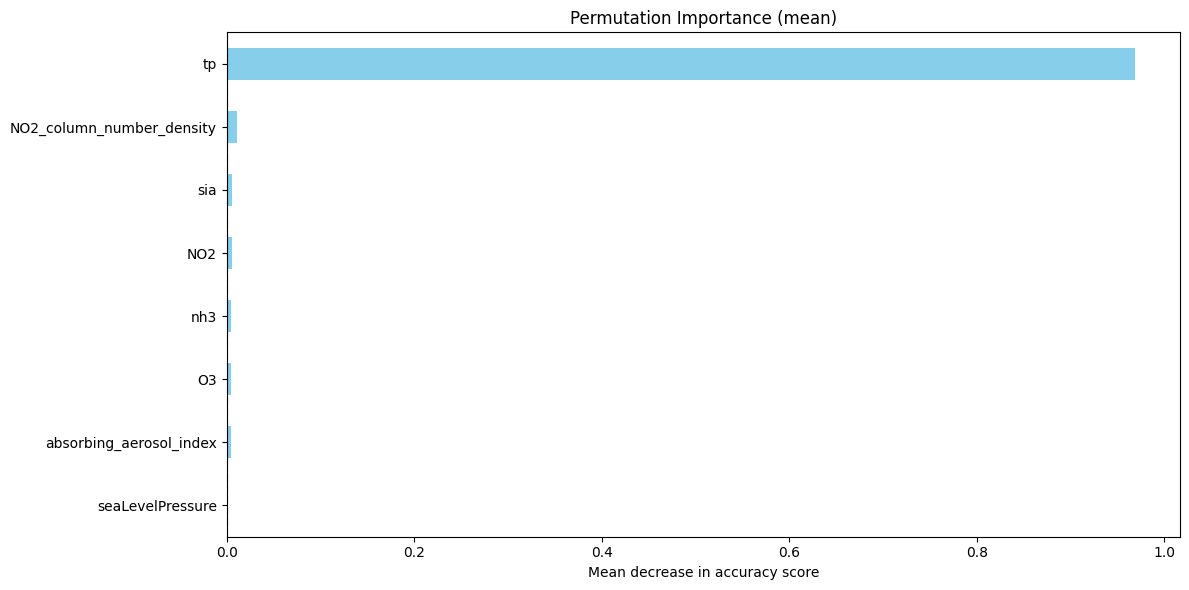

In [18]:
result = permutation_importance(rf_default, X_test, y_test, n_repeats=5, random_state=123)
sorted_importances_idx = result.importances_mean.argsort()
importances_df = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_test.columns[sorted_importances_idx]
)

forest_importances = pd.Series(result.importances_mean, index=X_test.columns)
forest_importances = forest_importances[forest_importances > 0]
forest_importances = forest_importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
forest_importances.plot.barh(ax=ax, color='skyblue')
ax.set_title("Permutation Importance (mean)")
ax.set_xlabel("Mean decrease in accuracy score")
ax.axvline(x=0, color="k", linestyle="--")

fig.tight_layout()
plt.show()

In [19]:
forest_importances

seaLevelPressure             0.000849
absorbing_aerosol_index      0.004161
O3                           0.004748
nh3                          0.004898
NO2                          0.005241
sia                          0.005300
NO2_column_number_density    0.010696
tp                           0.968338
dtype: float64

## Optimalių hiperparametrų atrinkimas

In [25]:
X_train.columns

Index(['tp', 'pm10', 'H2O_column_number_density', 'dust', 'O3',
       'absorbing_aerosol_index', 'sia', 'NO2_column_number_density', 'pans',
       'nh3', 'NO2_slant_column_number_density', 'seaLevelPressure', 'NO2',
       'H2O_column_number_density_lag-1', 'dust-1', 'pans_lag-10',
       'nh3_lag-1'],
      dtype='object')

In [ ]:
# param_grid = {
#     'n_estimators': [50, 100, 150, 200],
#     'max_depth': [None, 4, 16, 32, 64], 
#     'min_samples_split': [2, 4, 6, 8],
#     'min_samples_leaf': [1, 2, 3, 4]
# }

# rf = RandomForestRegressor(random_state=123)

# tscv = TimeSeriesSplit(n_splits=5)
# grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=tscv)
# grid_search.fit(X_train, y_train)

# best_model = grid_search.best_estimator_

# print(f"Geriausi parametrai: {grid_search.best_params_}")
# print(f"Tikslumas: {grid_search.best_score_:.4f}")

Geriausi parametrai: {'max_depth': 16, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 50}
Tikslumas: 0.4086


In [ ]:
# rf_h = RandomForestRegressor(max_depth = 4, n_estimators = 200, random_state=123)
# rf_h.fit(X_train, y_train)
# rf_h_pred_val = rf_h.predict(X_val)

# metrics_fun(y_val, rf_h_pred_val)

R^2:  0.45398855137269
MAE:  1.49226310652723
RMSE: 4.178800873853899
r_s:  0.676


In [ ]:
# rf_h = RandomForestRegressor(max_depth = 16, n_estimators = 50, min_samples_leaf = 3, min_samples_split = 2, random_state=123)
# rf_h.fit(X_train, y_train)
# rf_h_pred_val = rf_h.predict(X_val)

# metrics_fun(y_val, rf_h_pred_val)

R^2:  0.3945753361782438
MAE:  1.5413243730507342
RMSE: 4.4002855167028745
r_s:  0.697


### Vizualizacija

In [ ]:
# plot_df = val[['observationTime', 'target_precipitation']].copy()
# plot_df['prediction'] = rf_h_pred_val
# plot_df = plot_df.sort_values('observationTime')

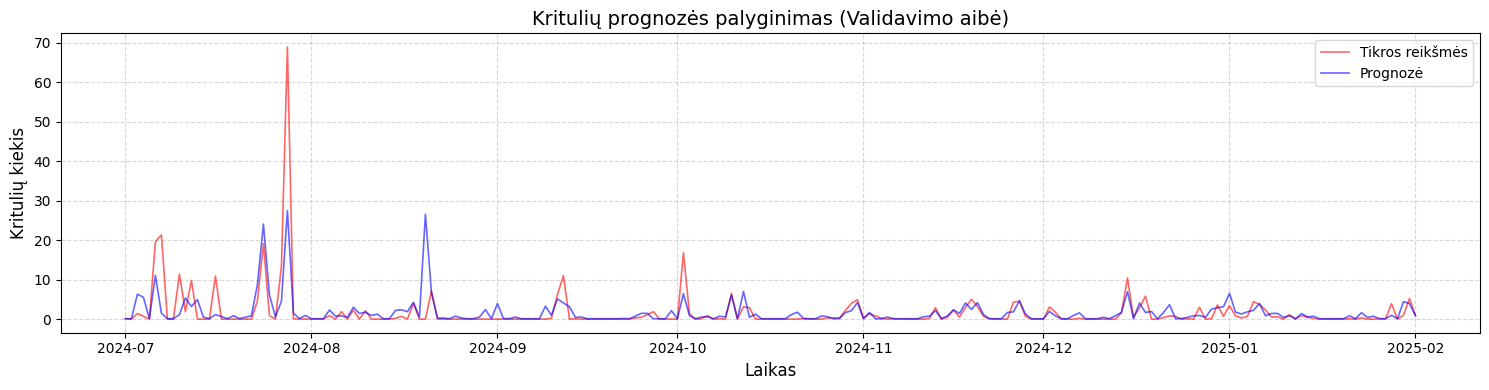

In [ ]:
# fig, ax1 = plt.subplots(figsize=(15, 4))
# ax1.plot(plot_df['observationTime'], plot_df['target_precipitation'], label='Tikros reikšmės', color='red', linewidth=1.2, alpha=0.6)
# ax1.plot(plot_df['observationTime'], plot_df['prediction'], label='Prognozė', color='blue', linewidth=1.2, alpha=0.6)
# ax1.legend(loc='upper right', fontsize=10, frameon=True)
# ax1.set_title("Kritulių prognozės palyginimas (Validavimo aibė)", fontsize=14)
# ax1.set_xlabel("Laikas", fontsize=12)
# ax1.set_ylabel("Kritulių kiekis", fontsize=12)
# ax1.grid(True, linestyle='--', alpha=0.5)

# fig.tight_layout()
# plt.show()